# The code behind it: standard error by simulation

*Part 2 · Lesson 11 · the code behind it  ·  data: Ames housing (same as Lesson 11)*

*↩ A companion to [Lesson 11: Estimation & standard error](11-estimation.ipynb).*

**↩ Back:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset →](11-estimation~another-dataset.ipynb)

**In Lesson 11 you watched the standard error appear** — thousands of sample means dancing around the true
average house size, with their spread landing exactly on $\sigma/\sqrt{n}$. It looked like the formula
*predicted* the simulation. This companion **opens the hood**: you'll build that simulation *yourself*, so
"standard error" stops being a formula you're handed and becomes a few lines of code you could write from
memory.

Same Ames homes, same headline numbers — but the focus shifts from *what the standard error means* to **how
you compute and confirm it in Python**. We'll go in the order a programmer actually works:

1. **The goal** — what we're building.
2. **The data in code** — load the population, find its true $\mu$ and $\sigma$.
3. **Build it step by step** — one estimate, then many; show the spread of the estimates *is* $\sigma/\sqrt{n}$, the $\sqrt{n}$ law, unbiasedness, and the SE from one sample.
4. **The idiom** — the explicit `for`-loop vs. the vectorized `(reps, n)` array (and why the array wins).
5. **Refactor into functions** — your own `standard_error()` and `sampling_distribution()`.
6. **Now you code** — predict-then-run exercises.
7. **What you learned** — the coding *and* the statistics.

You don't need Lesson 11 fresh in mind, but it helps. Run each grey cell with **Shift + Enter**, top to bottom.

> **New to notebooks?** The grey boxes below are **code**. Click one and press **Shift + Enter** to run it — the result (a number, a table, or a chart) appears right underneath. Run them **top to bottom**. You do **not** need to understand the first *"Setup"* cell — it just loads the tools and the data, so run it and move on. And you **can't break anything**: re-running a cell is always safe. *(Brand new to all this? The five-minute [Lesson 0 — How these notebooks work](00-how-these-notebooks-work.ipynb) shows you the basics first.)*

## 1) The goal

By the end of this notebook you'll have written the **engine** behind Lesson 11: code that treats a real
dataset as a *known population*, draws thousands of samples from it, and measures how far a sample average
typically lands from the truth — the **standard error**. With it you'll **numerically confirm** the famous
formula $\text{SE} = \sigma/\sqrt{n}$, watch the **$\sqrt{n}$ law** (quadruple the sample, halve the error),
see that the sample mean is **unbiased**, and learn how to estimate the SE from the **single** sample you'd
actually have in real life. Nothing here needs new statistics; everything is the Python *underneath* the
simulation the core lesson ran for you.

The tools we'll use, and what each is for:

| Tool | What it is | What we use it for |
|---|---|---|
| **pandas** | tables (`DataFrame`) and columns (`Series`) | loading the CSV and pulling out the area column |
| **NumPy** | fast math on whole arrays at once | the random sampling, the averaging, the $\sqrt{n}$ checks |
| **matplotlib** | plotting | the SE-vs-$n$ curve |

The one new tool is NumPy's **random generator**, `rng = np.random.default_rng(0)`. The `0` is a **seed**: it
fixes the dice so the notebook gives the *same* "random" numbers every time it runs (reproducible results).
Its workhorse method is `rng.choice(pop, size=..., replace=True)` — draw values at random from `pop`.

In [1]:
# --- Setup: load our helpers and the data --------------------------------
import sys, pathlib
for _p in [pathlib.Path.cwd(), pathlib.Path.cwd().parent]:
    if (_p / 'lib' / 'statslab.py').exists():
        sys.path.insert(0, str(_p / 'lib')); break
import statslab as sl

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sl.use_course_style()
rng = np.random.default_rng(0)   # fixed seed -> reproducible; the learner can change it

# The SAME data as the core lesson: every home's living area in Ames, Iowa.
AMES_URL = 'https://www.openintro.org/data/csv/ames.csv'
ames = sl.load_csv('ames.csv', url=AMES_URL)
print(f'Loaded a {type(ames).__name__} with shape {ames.shape}  (rows, columns)')

Loaded a DataFrame with shape (2930, 82)  (rows, columns)


## 2) The data in code

We'll treat the whole `area` column as our **population** — every home, no sampling yet — so we get to
*know* the true answer and check our simulation against it. This is the core lesson's clever trick: in a
real study you'd never know $\mu$, but by *declaring* the file the population we can grade our own work.

A programmer's first move is to *interrogate the object*: pull out the column, drop the missing values, and
turn it into a plain NumPy array (fast to sample from). Then compute the two numbers the standard error
cares about:

- the **population mean** $\mu$ = `pop.mean()`, and
- the **population standard deviation** $\sigma$ = `pop.std(ddof=0)`.

That `ddof=0` is deliberate: it divides by $n$, which is the **population** SD (we're treating this file as
the *entire* population, not a sample of it). This is the $\sigma$ that the formula $\sigma/\sqrt{n}$ uses,
so matching it later is an honest, apples-to-apples check. *(A **sample** SD, which you'd compute from a
handful of homes, uses `ddof=1` instead — divide by $n-1$. We'll meet that distinction head-on in Section 3.)*

In [2]:
# Pull out the living-area column, drop missing values, make a NumPy array.
pop = ames['area'].dropna().to_numpy()       # living area (sq ft) of every home

mu    = pop.mean()           # the TRUE population mean  (mu)
sigma = pop.std(ddof=0)      # the TRUE population SD (ddof=0 -> divide by n: this IS the whole population)
N_POP = len(pop)

print(f'population size      N = {N_POP:,} homes (living area, sq ft)')
print(f'population mean      mu    = {mu:.1f} sq ft   <- the answer we will try to estimate')
print(f'population SD        sigma = {sigma:.1f} sq ft')
print(f'median                     = {np.median(pop):.1f} sq ft')
print(f'min / max                  = {pop.min():.0f} / {pop.max():.0f} sq ft')

population size      N = 2,930 homes (living area, sq ft)
population mean      mu    = 1499.7 sq ft   <- the answer we will try to estimate
population SD        sigma = 505.4 sq ft
median                     = 1442.0 sq ft
min / max                  = 334 / 5642 sq ft


We have $\mu \approx 1{,}500$ sq ft and $\sigma \approx 505$ sq ft across about **2,930** homes. Those two
numbers are the *truth* — everything below estimates $\mu$ from small samples and checks how far off the
estimates run, knowing the real answer the whole time.

> **One assumption, stated once:** every sample below is drawn **with replacement** (`replace=True`), so a
> home *could* be picked twice. That models the file as an endless i.i.d. super-population — and it's exactly
> the condition under which $\sigma/\sqrt{n}$ is the **exact** target for the spread, letting us check the
> formula with a clean conscience.

## 3) Build it step by step

Here is the heart of it. We'll build the standard-error story in five short moves.

### Move 1 — one sample, one estimate (and it misses)

A **point estimate** is what you get from a single sample: draw `n` homes, average them. That one number
is our guess at $\mu$ — and because it's only a sample, it lands *near* the truth, not on it. The gap is
**sampling error**.

In [3]:
n = 50
sample = rng.choice(pop, size=n, replace=True)   # draw 50 homes at random, WITH replacement
xbar   = sample.mean()                           # the point estimate: our guess at mu

print(f'A sample of n = {n} homes:')
print(f'  point estimate  x-bar = {xbar:.1f} sq ft   (our guess)')
print(f'  true mean       mu    = {mu:.1f} sq ft   (the target)')
print(f'  sampling error        = {xbar - mu:+.1f} sq ft   <- we missed by this much')
print('Draw a different sample and the estimate moves. How much it typically moves is the STANDARD ERROR.')

A sample of n = 50 homes:
  point estimate  x-bar = 1502.2 sq ft   (our guess)
  true mean       mu    = 1499.7 sq ft   (the target)
  sampling error        = +2.5 sq ft   <- we missed by this much
Draw a different sample and the estimate moves. How much it typically moves is the STANDARD ERROR.


### Move 2 — the standard error, by simulation

The **standard error (SE)** is the *typical* size of that miss — formally, the **standard deviation of the
estimate across all the samples you could have drawn**. We can't see "all possible samples," but we can draw
a huge pile of them, collect their means, and measure how spread out the means are. That measured spread
*is* the standard error, made concrete.

Theory promises a shortcut: that spread should equal $\sigma/\sqrt{n}$. Let's draw 10,000 samples, measure
the spread of the estimates, and check it against the formula with `np.isclose`.

In [4]:
n    = 50
reps = 10_000                                            # moderate: runs in a moment
samples = rng.choice(pop, size=(reps, n), replace=True)  # 10,000 samples, one per row
xbars   = samples.mean(axis=1)                           # the 10,000 point estimates

empirical_SE = xbars.std(ddof=0)        # the ACTUAL spread of our 10,000 estimates
formula_SE   = sigma / np.sqrt(n)       # the textbook prediction sigma/sqrt(n)

print(f'Built {len(xbars):,} sample means, each from a sample of n = {n}.')
print(f'empirical SE  (measured spread of the estimates) = {empirical_SE:.2f} sq ft')
print(f'formula   SE  (sigma / sqrt(n))                   = {formula_SE:.2f} sq ft')
print('match?', np.isclose(empirical_SE, formula_SE, rtol=0.05))
print('-> sigma/sqrt(n) is not a magic spell: it literally predicts how spread out the estimates turned out.')

Built 10,000 sample means, each from a sample of n = 50.
empirical SE  (measured spread of the estimates) = 71.37 sq ft
formula   SE  (sigma / sqrt(n))                   = 71.48 sq ft
match? True
-> sigma/sqrt(n) is not a magic spell: it literally predicts how spread out the estimates turned out.


That `match? True` is the whole point of the lesson, proven by code: the standard-error formula is just
*describing the spread of the estimates we actually got*. (We use `ddof=0` for `xbars.std()` here because
we have the *entire* cloud of 10,000 estimates — it's a complete population of estimates, not a sample of
them.)

### Move 3 — the $\sqrt{n}$ law

The sample size sits under a **square root** in $\sigma/\sqrt{n}$. So to halve the SE you don't double the
data — you **quadruple** it. Watch it happen: we'll compute the SE at $n = 10, 40, 160, 640$ (each 4× the
last) and the SE should halve at every step.

In [5]:
sizes = [10, 40, 160, 640]                  # each is 4x the previous
rows = []
for nn in sizes:
    means = rng.choice(pop, size=(reps, nn), replace=True).mean(axis=1)
    rows.append({'n': nn,
                 'empirical_SE': means.std(ddof=0),
                 'formula_SE': sigma / np.sqrt(nn)})
se_table = pd.DataFrame(rows)
print(se_table.to_string(index=False, float_format=lambda v: f'{v:.2f}'))

print('\nEach time n goes UP 4x, the SE comes DOWN by about half:')
for i in range(1, len(se_table)):
    drop = se_table['formula_SE'].iloc[i-1] / se_table['formula_SE'].iloc[i]
    print(f"  n {se_table['n'].iloc[i-1]:>4} -> {se_table['n'].iloc[i]:>4} (4x data): "
          f"SE shrank by factor {drop:.2f}  (target 2.00)")
print('all rows match the formula within 5%?',
      np.allclose(se_table['empirical_SE'], se_table['formula_SE'], rtol=0.05))

  n  empirical_SE  formula_SE
 10        159.34      159.83
 40         79.31       79.91
160         39.89       39.96
640         19.89       19.98

Each time n goes UP 4x, the SE comes DOWN by about half:
  n   10 ->   40 (4x data): SE shrank by factor 2.00  (target 2.00)
  n   40 ->  160 (4x data): SE shrank by factor 2.00  (target 2.00)
  n  160 ->  640 (4x data): SE shrank by factor 2.00  (target 2.00)
all rows match the formula within 5%? True


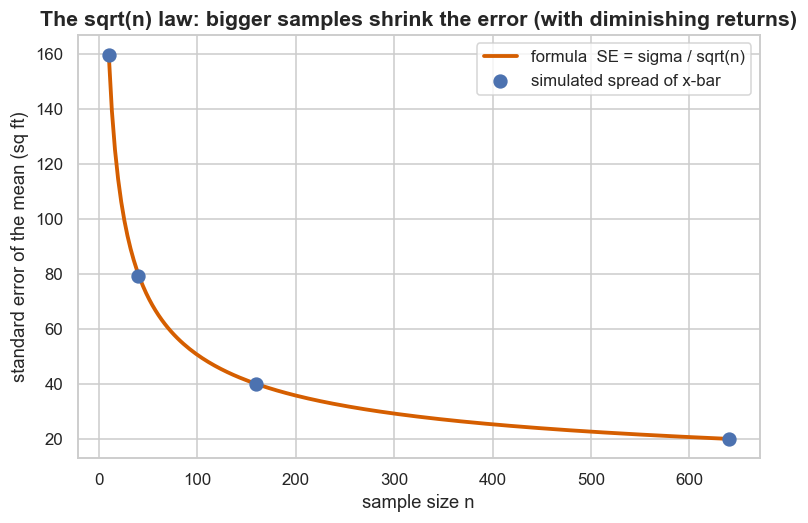

The dots sit right on the curve, and it FLATTENS: the drop from n=10 to n=160 is dramatic,
but from n=160 to n=640 it is barely visible -- the diminishing returns of more data.


In [6]:
# Picture the sqrt(n) law: dots = simulation, smooth curve = sigma/sqrt(n).
nn_grid = np.linspace(10, 640, 200)
fig, ax = plt.subplots()
ax.plot(nn_grid, sigma / np.sqrt(nn_grid), color='#D55E00', lw=2.5,
        label=r'formula  SE = sigma / sqrt(n)')
ax.scatter(se_table['n'], se_table['empirical_SE'], s=70, color='#4c72b0', zorder=5,
           label='simulated spread of x-bar')
ax.set_xlabel('sample size n'); ax.set_ylabel('standard error of the mean (sq ft)')
ax.set_title('The sqrt(n) law: bigger samples shrink the error (with diminishing returns)')
ax.legend(); plt.show()

print('The dots sit right on the curve, and it FLATTENS: the drop from n=10 to n=160 is dramatic,')
print('but from n=160 to n=640 it is barely visible -- the diminishing returns of more data.')

### Move 4 — unbiased, and why `ddof=1` exists

Two estimators worth separating:

- The **sample mean** $\bar{x}$ is **unbiased** for $\mu$: average enough sample means and they pile up
  *right on* the truth, with no systematic pull either way. The `xbars` cloud from Move 2 should average to
  $\mu$.
- The **plug-in variance** (dividing the squared deviations by $n$) is **biased low** — it systematically
  underestimates $\sigma^2$. Dividing by $n-1$ instead (`ddof=1`, *Bessel's correction*) fixes it. That is
  the entire reason `ddof=1` exists, and we can *see* the bias by averaging both versions over many samples.

In [7]:
# (a) the sample MEAN is unbiased: the cloud of estimates centers on mu.
print(f'mean of the 10,000 sample means = {xbars.mean():.2f} sq ft')
print(f'true population mean mu         = {mu:.2f} sq ft')
print(f'bias (difference)               = {xbars.mean() - mu:+.2f} sq ft   <- essentially 0: UNBIASED')

# (b) the plug-in variance (divide by n) runs SMALL; ddof=1 (divide by n-1) corrects it.
var_n   = np.array([rng.choice(pop, size=20, replace=True).var(ddof=0) for _ in range(reps)])  # /n
var_nm1 = np.array([rng.choice(pop, size=20, replace=True).var(ddof=1) for _ in range(reps)])  # /(n-1)
true_var = sigma ** 2

print(f'\nAveraged over {reps:,} samples of n = 20:')
print(f'  avg variance, divide by n     (ddof=0) = {var_n.mean():,.0f}   <- too small (biased low)')
print(f'  avg variance, divide by n-1   (ddof=1) = {var_nm1.mean():,.0f}   <- lands on the truth')
print(f'  true population variance sigma^2       = {true_var:,.0f}')
print("That gap is exactly why a SAMPLE SD uses ddof=1 -- and why our s/sqrt(n) below uses it too.")

mean of the 10,000 sample means = 1500.17 sq ft
true population mean mu         = 1499.69 sq ft
bias (difference)               = +0.47 sq ft   <- essentially 0: UNBIASED



Averaged over 10,000 samples of n = 20:
  avg variance, divide by n     (ddof=0) = 242,101   <- too small (biased low)
  avg variance, divide by n-1   (ddof=1) = 255,176   <- lands on the truth
  true population variance sigma^2       = 255,452
That gap is exactly why a SAMPLE SD uses ddof=1 -- and why our s/sqrt(n) below uses it too.


### Move 5 — the SE from a *single* sample (real life)

In Move 2 we used 10,000 samples and the true $\sigma$. But in a real study you get **one** sample, and you
**don't know $\sigma$**. So you estimate the standard error by swapping in the sample SD $s$ (with `ddof=1`,
because it's a *sample*):

$$\widehat{\text{SE}}(\bar{x}) \;=\; \frac{s}{\sqrt{n}}.$$

Does that single-sample estimate land near the true SE we simulated? Let's check.

In [8]:
# In real life you get ONE sample and must estimate the SE from it alone.
one_sample = rng.choice(pop, size=n, replace=True)
s_one  = one_sample.std(ddof=1)             # sample SD: ddof=1 because it's a SAMPLE
SE_hat = s_one / np.sqrt(n)                  # estimated standard error, from one sample

true_SE = sigma / np.sqrt(n)                 # the true SE (uses the unknown-in-real-life sigma)
print(f'From a single sample of n = {n}:')
print(f'  point estimate  x-bar    = {one_sample.mean():.1f} sq ft')
print(f'  sample SD       s        = {s_one:.1f} sq ft')
print(f'  estimated SE = s/sqrt(n) = {SE_hat:.2f} sq ft')
print(f'  true SE  = sigma/sqrt(n) = {true_SE:.2f} sq ft   <- our one-sample guess is close')
print(f'\nReport it as:  mu is about {one_sample.mean():.0f} sq ft, give or take ~{SE_hat:.0f} sq ft.')
print('SD vs SE: s describes how much HOMES vary; s/sqrt(n) describes how much the AVERAGE varies.')

From a single sample of n = 50:
  point estimate  x-bar    = 1547.4 sq ft
  sample SD       s        = 579.0 sq ft
  estimated SE = s/sqrt(n) = 81.89 sq ft
  true SE  = sigma/sqrt(n) = 71.48 sq ft   <- our one-sample guess is close

Report it as:  mu is about 1547 sq ft, give or take ~82 sq ft.
SD vs SE: s describes how much HOMES vary; s/sqrt(n) describes how much the AVERAGE varies.


## 4) The idiom — the loop vs. the vectorized `(reps, n)` array

In Move 2 we built the estimates with `rng.choice(pop, size=(reps, n))` — a **2D array of shape `(reps, n)`**,
which is `reps` samples stacked as rows, each row a sample of `n` homes — then averaged **across each row**
with `.mean(axis=1)`. Read `axis=1` as **"collapse each row to its mean."** The literal alternative is an
explicit `for` loop. They give the *same* answer; the array is one expression and far faster.

To prove they agree, we reset the seed before each so they see the *same* random draws.

In [9]:
n, reps = 50, 10_000

# (a) the explicit loop
rng_loop = np.random.default_rng(0)
loop_means = []
for _ in range(reps):
    loop_means.append(rng_loop.choice(pop, size=n, replace=True).mean())
loop_means = np.array(loop_means)

# (b) the vectorized (reps, n) array idiom
rng_vec = np.random.default_rng(0)
samples   = rng_vec.choice(pop, size=(reps, n), replace=True)   # shape (10000, 50)
vec_means = samples.mean(axis=1)                                # one mean per row

print('samples array shape:', samples.shape, ' -> (reps, n): one sample per row')
print(f'loop       : SE of estimates = {loop_means.std(ddof=0):.2f} sq ft')
print(f'vectorized : SE of estimates = {vec_means.std(ddof=0):.2f} sq ft')
print('identical (same seed -> same draws)?', np.allclose(loop_means, vec_means))

samples array shape: (10000, 50)  -> (reps, n): one sample per row
loop       : SE of estimates = 71.36 sq ft
vectorized : SE of estimates = 71.36 sq ft
identical (same seed -> same draws)? True


In [10]:
# And the vectorized way is much faster. Time both on a big run.
import time
n, reps = 50, 50_000

t0 = time.perf_counter()
m = []
for _ in range(reps):
    m.append(rng.choice(pop, size=n, replace=True).mean())
t_loop = time.perf_counter() - t0

t0 = time.perf_counter()
_ = rng.choice(pop, size=(reps, n), replace=True).mean(axis=1)
t_vec = time.perf_counter() - t0

print(f'{reps:,} samples of n = {n}:')
print(f'  Python loop          : {t_loop*1000:7.1f} ms')
print(f'  vectorized (reps, n) : {t_vec*1000:7.1f} ms')
print(f'  vectorized is roughly {t_loop/max(t_vec,1e-9):.0f}x faster -- and it is one short line.')

50,000 samples of n = 50:
  Python loop          :   678.7 ms
  vectorized (reps, n) :    20.9 ms
  vectorized is roughly 33x faster -- and it is one short line.


## 5) Refactor into reusable functions

You've now written "sample SD over root-n" and "draw-average-collect" a few times. The programmer's reflex
is to **wrap repeated work in a function**: name it, give it inputs, `return` the result. Two functions
capture the whole lesson — one for the *estimated* SE from a single sample, one for the *simulated*
sampling distribution we check it against.

In [11]:
def standard_error(sample):
    '''Estimate the standard error of the mean from ONE sample: s / sqrt(n), with ddof=1.

    This is the real-life SE: it uses only the sample (never the unknown population sigma).
    '''
    sample = np.asarray(sample)
    return sample.std(ddof=1) / np.sqrt(len(sample))


def sampling_distribution(pop, n, reps, rng):
    '''Return an array of `reps` sample means, each from a sample of size n drawn
    (with replacement) from the 1-D population array `pop`, using generator `rng`.

    The vectorized idiom from Section 4: one (reps, n) array, averaged per row.
    '''
    samples = rng.choice(pop, size=(reps, n), replace=True)
    return samples.mean(axis=1)


# Reuse both across several sizes -- no copy-paste of the recipe.
rng = np.random.default_rng(0)
print(f"{'n':>4} {'true SE (sim)':>14} {'formula SE':>12} {'1-sample SE-hat':>16} {'match?':>8}")
for n in [10, 40, 160, 640]:
    means    = sampling_distribution(pop, n, reps=10_000, rng=rng)   # simulated sampling distribution
    true_se  = means.std(ddof=0)                                     # its spread = the true SE
    formula  = sigma / np.sqrt(n)                                    # the formula
    one      = rng.choice(pop, size=n, replace=True)                 # one real-life sample
    se_hat   = standard_error(one)                                   # estimate SE from that sample alone
    print(f'{n:>4} {true_se:>14.2f} {formula:>12.2f} {se_hat:>16.2f} '
          f'{str(np.isclose(true_se, formula, rtol=0.05)):>8}')

   n  true SE (sim)   formula SE  1-sample SE-hat   match?
  10         160.19       159.83           136.79     True
  40          79.83        79.91            63.38     True
 160          39.86        39.96            35.38     True
 640          19.84        19.98            21.10     True


Two functions are two contracts. `standard_error(sample)` says *give me one sample, I'll tell you how
trustworthy its average is.* `sampling_distribution(pop, n, reps, rng)` says *give me a population and a
sample size, I'll show you how the estimate would dance.* Once they're correct you stop thinking about loops
and start thinking in **estimates, standard errors and sample sizes** — exactly the leap from "watching the
standard error" to "computing it in code." The single-sample `SE-hat` column tracks the true SE at every
$n$, which is *why* a lone sample is enough to report a margin in real life.

## 6) Now you code

Write the code yourself. Add a new cell (the **+** button in the toolbar) and try each — predict the answer
before you run it.

1. **Quadruple $n$, halve the SE.** Use `sampling_distribution(pop, n, 10_000, rng)` to get the SE (the
   `.std(ddof=0)` of the result) at `n = 50` and at `n = 200` (a 4× jump). Predict the *ratio* of the two
   SEs before you run — the $\sqrt{n}$ law says it should be near **2.00**.

2. **Trust the single-sample SE.** Draw one sample of `n = 100` and call `standard_error(sample)`. Compare it
   to the true `sigma / np.sqrt(100)`. Now re-draw a few times (re-run the cell): the `SE-hat` wobbles a
   little around the truth, but stays close — that wobble is why bigger samples give steadier SE estimates.

3. **See the bias of dividing by $n$.** For `n = 10`, build `var(ddof=0)` and `var(ddof=1)` for 5,000 samples
   (as in Move 4) and print each average next to `sigma**2`. Which one lands on the truth? By roughly what
   factor is the `ddof=0` version too small? (Hint: it's about $(n-1)/n$.)

4. **A different column.** The SE story works on *any* numeric column. Set
   `pop2 = ames['price'].dropna().to_numpy()` and `sigma2 = pop2.std(ddof=0)`, then check that
   `sampling_distribution(pop2, 50, 10_000, rng).std(ddof=0)` still matches `sigma2 / np.sqrt(50)`. (It
   should — the formula doesn't care which column.)

## What you learned

**Coding**
- NumPy's **random generator** `rng = np.random.default_rng(0)` gives reproducible randomness; `rng.choice(pop,
  size=..., replace=True)` draws samples **with replacement**.
- The **draw → average → repeat** recipe builds a sampling distribution. The explicit `for`-loop and the
  **vectorized `(reps, n)` array** (then `.mean(axis=1)`, "collapse each row to its mean") give the *same*
  answer — but the array is one line and far faster.
- **`ddof` is a deliberate choice:** `ddof=0` (divide by $n$) for a known **population** $\sigma$ or for the
  spread of a complete cloud of estimates; `ddof=1` (divide by $n-1$) for a **sample** SD.
- Use `np.isclose` / `np.allclose` to **check two numbers agree** to a tolerance — the programmer's way to
  confirm a formula against a simulation.
- **Refactor repeated work into functions** with clear inputs, a docstring and a `return`, then reuse them on
  any `n` or any column.

**Statistics (now demystified)**
- A single sample gives a **point estimate** of $\mu$ that misses by some **sampling error**; the
  **standard error** is the *typical* size of that miss.
- The **standard error IS the spread of the estimates**: the SD of 10,000 simulated sample means matched the
  formula $\sigma/\sqrt{n}$ to a hair (`match? True`). The formula merely *describes* that spread.
- The **$\sqrt{n}$ law**: each 4× jump in sample size halved the SE — with diminishing returns, so doubling
  precision costs four times the data.
- The sample mean is **unbiased** (the cloud of estimates averaged onto $\mu$); the plug-in variance
  (divide by $n$) is **biased low**, which is exactly why a sample SD divides by $n-1$ (`ddof=1`).
- In real life you have **one** sample, so you estimate the SE as $s/\sqrt{n}$ — and that single-sample
  estimate tracked the true SE at every $n$. (Standard deviation $s$ measures how much *homes* vary;
  standard error $s/\sqrt{n}$ measures how much the *average* varies, and shrinks with $n$.)

**Back to the core lesson** ([Lesson 11: Estimation & standard error](11-estimation.ipynb)) for the *meaning*
of these numbers, or read on through the course.

---

**↩ Back to the lesson:** [Lesson 11: Estimation & standard error](11-estimation.ipynb)  ·  [↑ Course map](../rendered/index.html)  ·  **Also:** [Another dataset](11-estimation~another-dataset.ipynb)